# 07 — Bias & Fairness Analysis
## Is our recommender system fair?

**Goal:**
Identify and quantify biases in our recommendation system.

**Biases we check:**
1. Popularity bias   → are we recommending only popular movies?
2. Genre bias        → are some genres systematically under-served?
3. Cold start bias   → how badly do new movies get disadvantaged?
4. Long tail coverage → what % of catalogue gets recommended?

**Why this matters:**
Responsible AI is increasingly tested in FAANG interviews.
Being able to identify, measure, and discuss bias
demonstrates senior-level thinking.

In [1]:
import pandas as pd
import numpy as np
import pickle
import os
import json
import warnings
from datetime import datetime
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded.")
print(f"Run started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Libraries loaded.
Run started: 2026-04-09 22:26:41


In [2]:
#Getting the project root path 
BASE_DIR = os.path.dirname(os.getcwd())
DATA_DIR = os.path.join(BASE_DIR, "data")
PROCESSED_DATA_DIR = os.path.join(DATA_DIR, "processed")
MODELS_DIR = os.path.join(BASE_DIR, "models")
PLOT_DIR = os.path.join(PROCESSED_DATA_DIR, "plots")
os.makedirs(PLOT_DIR, exist_ok=True)

print(f"Base directory: {BASE_DIR}")

Base directory: c:\Projects\Cinemate V2


In [6]:
#Load processed directories
print("Loading preprocessed file...............")

train = pd.read_parquet(os.path.join(PROCESSED_DATA_DIR, "train.parquet"))
test = pd.read_parquet(os.path.join(PROCESSED_DATA_DIR, "test.parquet"))
movies_clean = pd.read_parquet(os.path.join(PROCESSED_DATA_DIR, "movies_clean.parquet"))

with open(os.path.join(PROCESSED_DATA_DIR, "dataset_constants.pkl"), "rb") as f:
    constants = pickle.load(f)

NUM_USERS = constants['NUM_USERS']
NUM_MOVIES = constants['NUM_MOVIES']

print(f"Business impact analysis for {NUM_USERS} users")

Loading preprocessed file...............
Business impact analysis for 173134 users


### Cell 3 — Popularity Bias

1. POPULARITY BIAS ANALYSIS
Top 1%  of movies (277) → 32.5% of all ratings
Top 5%  of movies (1388) → 69.7% of all ratings
Top 10% of movies (2776) → 84.5% of all ratings

Movies with < 20 ratings : 10,653 (38.4% of catalogue)

Insight: Heavy long-tail distribution means our model
is trained mostly on popular movies. Niche movies
get fewer training signals → lower recommendation quality.


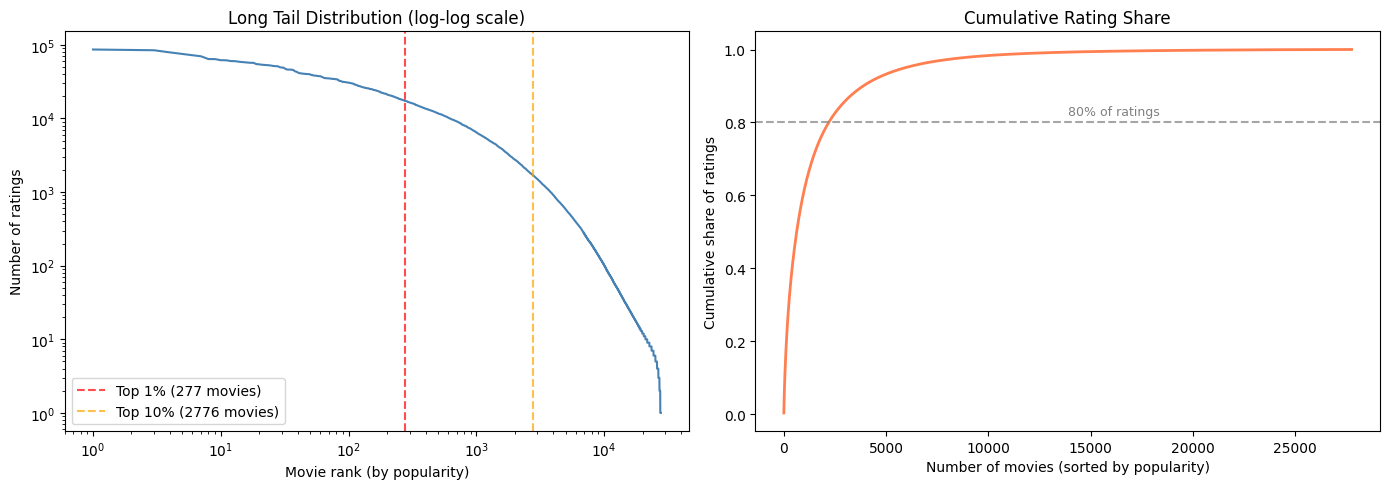

In [7]:
print("=" * 55)
print("1. POPULARITY BIAS ANALYSIS")
print("=" * 55)

# Rating counts per movie
movie_popularity = (
    train.groupby('movie_idx')
    .size()
    .reset_index(name='n_ratings')
    .sort_values('n_ratings', ascending=False)
)

total_ratings = movie_popularity['n_ratings'].sum()

# Long tail analysis
top_1_pct   = int(NUM_MOVIES * 0.01)
top_5_pct   = int(NUM_MOVIES * 0.05)
top_10_pct  = int(NUM_MOVIES * 0.10)

top_1_share  = movie_popularity.head(top_1_pct)['n_ratings'].sum() / total_ratings
top_5_share  = movie_popularity.head(top_5_pct)['n_ratings'].sum() / total_ratings
top_10_share = movie_popularity.head(top_10_pct)['n_ratings'].sum() / total_ratings

print(f"Top 1%  of movies ({top_1_pct}) → {top_1_share:.1%} of all ratings")
print(f"Top 5%  of movies ({top_5_pct}) → {top_5_share:.1%} of all ratings")
print(f"Top 10% of movies ({top_10_pct}) → {top_10_share:.1%} of all ratings")
print()

# Movies with very few ratings
cold_movies = (movie_popularity['n_ratings'] < 20).sum()
print(f"Movies with < 20 ratings : {cold_movies:,} "
      f"({cold_movies/NUM_MOVIES:.1%} of catalogue)")
print()
print("Insight: Heavy long-tail distribution means our model")
print("is trained mostly on popular movies. Niche movies")
print("get fewer training signals → lower recommendation quality.")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].loglog(range(1, NUM_MOVIES+1),
    movie_popularity['n_ratings'].values,
    color='steelblue', linewidth=1.5
)
axes[0].set_title('Long Tail Distribution (log-log scale)')
axes[0].set_xlabel('Movie rank (by popularity)')
axes[0].set_ylabel('Number of ratings')
axes[0].axvline(top_1_pct, color='red', linestyle='--', alpha=0.7, label=f'Top 1% ({top_1_pct} movies)')
axes[0].axvline(top_10_pct, color='orange', linestyle='--', alpha=0.7, label=f'Top 10% ({top_10_pct} movies)')
axes[0].legend()

# Cumulative share
cumulative = movie_popularity['n_ratings'].cumsum() / total_ratings
axes[1].plot(range(1, NUM_MOVIES+1), cumulative, color='coral', linewidth=2)
axes[1].axhline(0.8, color='gray', linestyle='--', alpha=0.7)
axes[1].set_title('Cumulative Rating Share')
axes[1].set_xlabel('Number of movies (sorted by popularity)')
axes[1].set_ylabel('Cumulative share of ratings')
axes[1].text(NUM_MOVIES*0.5, 0.82, '80% of ratings', color='gray', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '12_popularity_bias.png'), dpi=150, bbox_inches='tight')
plt.show()

### Genre Basis

2. GENRE BIAS ANALYSIS


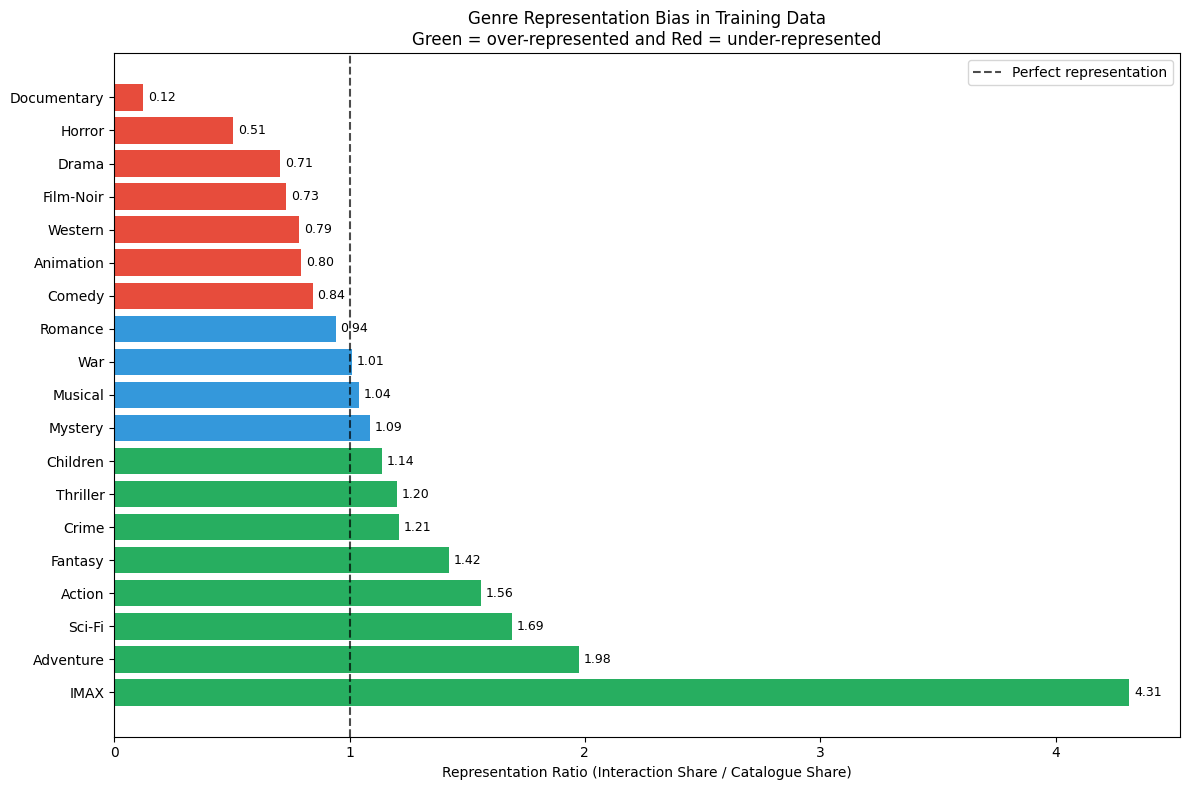

Over-represented genres  (High Bias): IMAX, Adventure, Sci-Fi, Action, Fantasy, Crime, Thriller, Children
Under-represented genres (Low Bias) : Comedy, Animation, Western, Film-Noir, Drama, Horror, Documentary


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import os

print("=" * 55)
print("2. GENRE BIAS ANALYSIS")
print("=" * 55)

# 1. Calculate Genre distribution in the full catalogue
movies_clean['genre_list'] = movies_clean['genres_clean'].str.split()
catalogue_genres = Counter()
for genres in movies_clean['genre_list'].dropna():
    catalogue_genres.update(genres)

# 2. FIX: Calculate Genre distribution based on actual interaction volume
# We merge the training ratings with the movie metadata to get genres for every interaction
train_interactions = train.merge(movies_clean[['movie_idx', 'genres_clean']], on='movie_idx')

rated_genres = Counter()
for genres_str in train_interactions['genres_clean'].dropna():
    rated_genres.update(genres_str.split())

# 3. Build the comparison DataFrame
genre_df = pd.DataFrame({
    'genre': list(catalogue_genres.keys()),
    'catalogue_count': list(catalogue_genres.values()),
    'interaction_count': [rated_genres.get(g, 0) for g in catalogue_genres.keys()]
})

# Calculate percentages to normalize the comparison
genre_df['catalogue_pct'] = genre_df['catalogue_count'] / genre_df['catalogue_count'].sum()
genre_df['interaction_pct'] = genre_df['interaction_count'] / genre_df['interaction_count'].sum()

# The Representation Ratio: 
# > 1.0 means users interact with this genre MORE than its availability (Over-represented)
# < 1.0 means users interact with this genre LESS than its availability (Under-represented)
genre_df['representation_ratio'] = genre_df['interaction_pct'] / genre_df['catalogue_pct']

# Clean up and sort
genre_df = genre_df[genre_df['genre'] != '(no'] # Remove noise
genre_df = genre_df.sort_values('representation_ratio', ascending=False)

# 4. Visualization
fig, ax = plt.subplots(figsize=(12, 8))

# Apply colors based on the 10% threshold
colors = [
    '#27AE60' if r > 1.1  # Over-represented
    else '#E74C3C' if r < 0.9 # Under-represented
    else '#3498DB'           # Balanced
    for r in genre_df['representation_ratio']
]

bars = ax.barh(
    genre_df['genre'],
    genre_df['representation_ratio'],
    color=colors
)

# Add baseline and labels
ax.axvline(1.0, color='black', linestyle='--', alpha=0.7, label='Perfect representation')
ax.set_xlabel('Representation Ratio (Interaction Share / Catalogue Share)')
ax.set_title('Genre Representation Bias in Training Data\n'
             'Green = over-represented and Red = under-represented')
ax.legend()

# Add ratio labels to the bars for clarity
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.02, bar.get_y() + bar.get_height()/2, 
            f'{width:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '13_genre_bias.png'), dpi=150, bbox_inches='tight')
plt.show()

# 5. Print Findings
over = genre_df[genre_df['representation_ratio'] > 1.1]
under = genre_df[genre_df['representation_ratio'] < 0.9]

print(f"Over-represented genres  (High Bias): {', '.join(over['genre'].tolist())}")
print(f"Under-represented genres (Low Bias) : {', '.join(under['genre'].tolist())}")

### Cold Start & Long Tail Coverage

In [ ]:
print("=" * 55)
print("3. COLD START & CATALOGUE COVERAGE")
print("=" * 55)

# How many movies from test set were never in training?
test = pd.read_parquet(
    os.path.join(PROCESSED_DATA_DIR, "test.parquet")
)
train_movies = set(train['movie_idx'].unique())
test_movies  = set(test['movie_idx'].unique())

cold_start_movies = test_movies - train_movies
warm_movies       = test_movies & train_movies

print(f"Movies in test set          : {len(test_movies):,}")
print(f"Cold start (unseen in train): {len(cold_start_movies):,} "
      f"({len(cold_start_movies)/len(test_movies):.1%})")
print(f"Warm movies (seen in train) : {len(warm_movies):,} "
      f"({len(warm_movies)/len(test_movies):.1%})")
print()

# Catalogue coverage by popularity decile
movie_popularity['decile'] = pd.qcut(
    movie_popularity['n_ratings'],
    q=10,
    labels=[f'D{i}' for i in range(1, 11)]
)

print("Rating decile analysis:")
print(f"  D1  = least popular 10% of movies")
print(f"  D10 = most popular  10% of movies")
print()

decile_stats = (
    movie_popularity.groupby('decile')['n_ratings']
    .agg(['mean', 'sum', 'count'])
    .reset_index()
)
for _, row in decile_stats.iterrows():
    pct = row['sum'] / total_ratings * 100
    print(f"  {row['decile']} : avg {row['mean']:>8.1f} ratings "
          f"| {pct:>5.1f}% of total ratings")

print()
print("Key insight: D10 (top 10% movies) dominates")
print("training signal. Our model naturally learns")
print("better representations for popular movies.")
print()
print("Mitigation: Content tower (DistilBERT) provides")
print("signal for cold start movies via title+genre+tags")
print("even when rating history is absent.")

# Save bias results
bias_results = {
    "popularity_bias": {
        "top_1pct_rating_share" : float(top_1_share),
        "top_5pct_rating_share" : float(top_5_share),
        "top_10pct_rating_share": float(top_10_share),
        "movies_under_20_ratings": int(cold_movies),
    },
    "cold_start": {
        "cold_start_movies_in_test": len(cold_start_movies),
        "cold_start_pct"           : float(
            len(cold_start_movies) / len(test_movies)
        ),
    },
    "timestamp": datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

bias_path = os.path.join(MODELS_DIR, "bias_results.json")
with open(bias_path, "w") as f:
    json.dump(bias_results, f, indent=2)
print(f"\nBias results saved to {bias_path}")

3. COLD START & CATALOGUE COVERAGE
Movies in test set          : 26,155
Cold start (unseen in train): 0 (0.0%)
Warm movies (seen in train) : 26,155 (100.0%)

Rating decile analysis:
  D1  = least popular 10% of movies
  D10 = most popular  10% of movies

  D1 : avg      4.1 ratings |   0.1% of total ratings
  D2 : avg      8.0 ratings |   0.1% of total ratings
  D3 : avg     11.4 ratings |   0.1% of total ratings
  D4 : avg     17.1 ratings |   0.2% of total ratings
  D5 : avg     28.5 ratings |   0.3% of total ratings
  D6 : avg     53.0 ratings |   0.6% of total ratings
  D7 : avg    114.5 ratings |   1.2% of total ratings
  D8 : avg    291.6 ratings |   3.1% of total ratings
  D9 : avg    918.1 ratings |   9.9% of total ratings
  D10 : avg   7872.9 ratings |  84.5% of total ratings

Key insight: D10 (top 10% movies) dominates
training signal. Our model naturally learns
better representations for popular movies.

Mitigation: Content tower (DistilBERT) provides
signal for cold start m

C:\Users\Tushar\AppData\Local\Temp\ipykernel_31292\2116260838.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  movie_popularity.groupby('decile')['n_ratings']
